In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/names_results2.db")

In [2]:
# Total dataset size
total = pd.read_sql("SELECT COUNT(*) AS total FROM names", engine).iloc[0, 0]
print(f"Total names: {total:,}")

Total names: 727,352


In [3]:
# Hunspell coverage counts
counts = pd.read_sql(
    """
    SELECT
        SUM(hunspell_orig_known)  AS orig_known,
        SUM(hunspell_latin_known) AS latin_known,
        SUM(hunspell_orig_known OR hunspell_latin_known) AS either_known,
        COUNT(*) AS total
    FROM names
    """,
    engine
)

counts["orig_pct"]   = counts["orig_known"]   / counts["total"] * 100
counts["latin_pct"]  = counts["latin_known"]  / counts["total"] * 100
counts["either_pct"] = counts["either_known"] / counts["total"] * 100

counts

,orig_known,latin_known,either_known,total,orig_pct,latin_pct,either_pct
0,18834,27999,27999,727352,2.589393,3.849443,3.849443


In [4]:
# Print readable summary
row = counts.iloc[0]
print(f"Known to hunspell (original form): {int(row.orig_known):,}  ({row.orig_pct:.2f}%)")
print(f"Known to hunspell (latin form):    {int(row.latin_known):,}  ({row.latin_pct:.2f}%)")
print(f"Known to hunspell (either form):   {int(row.either_known):,}  ({row.either_pct:.2f}%)")

Known to hunspell (original form): 18,834  (2.59%)
Known to hunspell (latin form):    27,999  (3.85%)
Known to hunspell (either form):   27,999  (3.85%)


In [5]:
# country_lang_comp coverage
clc = pd.read_sql(
    """
    SELECT
        SUM(country_lang_comp) AS clc_true,
        COUNT(*) AS total
    FROM names
    """,
    engine
)

clc["clc_pct"] = clc["clc_true"] / clc["total"] * 100

row = clc.iloc[0]
print(f"country_lang_comp = True: {int(row.clc_true):,}  ({row.clc_pct:.2f}%)")

clc

country_lang_comp = True: 137,830  (18.95%)


,clc_true,total,clc_pct
0,137830,727352,18.949559


In [28]:
# Load the columns needed for analysis
df = pd.read_sql(
    """
    SELECT
        name,
        name_script,
        top_country,
        top_country_langs,
        langdetect_lang,
        langdetect_lang_name,
        hunspell_orig_known,
        hunspell_latin_known,
        country_lang_comp
    FROM names
    """,
    engine
)

df.head()

,name,name_script,top_country,top_country_langs,langdetect_lang,langdetect_lang_name,hunspell_orig_known,hunspell_latin_known,country_lang_comp
0,A A Ron,Latin,United States,"[""en""]",hu,Hungarian,0,0,0
1,A Abdiel,Latin,Panama,"[""es""]",de,German,0,0,0
2,A Abera,Latin,Ethiopia,"[""am""]",hu,Hungarian,0,0,0
3,A Al,Latin,Bangladesh,"[""bn""]",hu,Hungarian,0,0,0
4,A Alberto,Latin,Costa Rica,"[""es""]",hu,Hungarian,0,0,0


In [30]:
import ast

# Convert string list to Python list if needed
if isinstance(df["top_country_langs"].iloc[0], str):
    df["top_country_langs"] = df["top_country_langs"].apply(ast.literal_eval)

# Primary language of predicted country
df["country_primary_lang"] = df["top_country_langs"].str[0]

# Hunspell flag indicators
df["hunspell_flag"] = ~df["hunspell_orig_known"]
df["hunspell_latin_flag"] = ~df["hunspell_latin_known"]

# Ensure hunspell columns are boolean
df["hunspell_orig_known"] = df["hunspell_orig_known"].astype(bool)
df["hunspell_latin_known"] = df["hunspell_latin_known"].astype(bool)

# Create proper flag columns
df["hunspell_flag"] = df["hunspell_orig_known"] == False
df["hunspell_latin_flag"] = df["hunspell_latin_known"] == False

df[["hunspell_orig_known","hunspell_flag"]].head()

,hunspell_orig_known,hunspell_flag
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


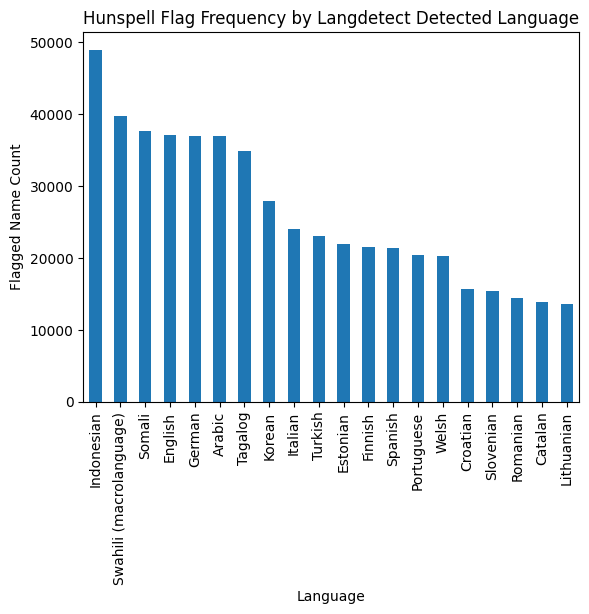

In [18]:
import matplotlib.pyplot as plt

flag_freq_lang = (
    df[df["hunspell_flag"]]
    ["langdetect_lang_name"]
    .value_counts()
)

flag_freq_lang.head(20).plot.bar()

plt.title("Hunspell Flag Frequency by Langdetect Detected Language")
plt.ylabel("Flagged Name Count")
plt.xlabel("Language")
plt.show()

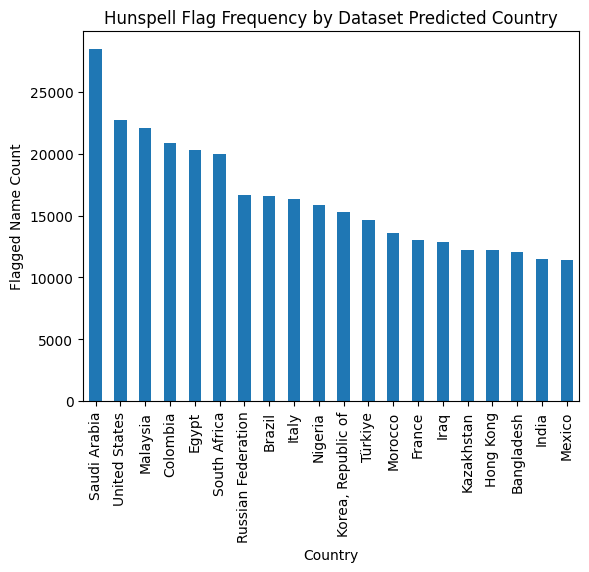

In [17]:
flag_freq_country = (
    df[df["hunspell_flag"]]
    ["top_country"]
    .value_counts()
)

flag_freq_country.head(20).plot.bar()

plt.title("Hunspell Flag Frequency by Dataset Predicted Country")
plt.ylabel("Flagged Name Count")
plt.xlabel("Country")
plt.show()

C:\Users\saras\AppData\Local\Temp\ipykernel_440\3486620119.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["hunspell_flag"].mean() - x["hunspell_latin_flag"].mean())


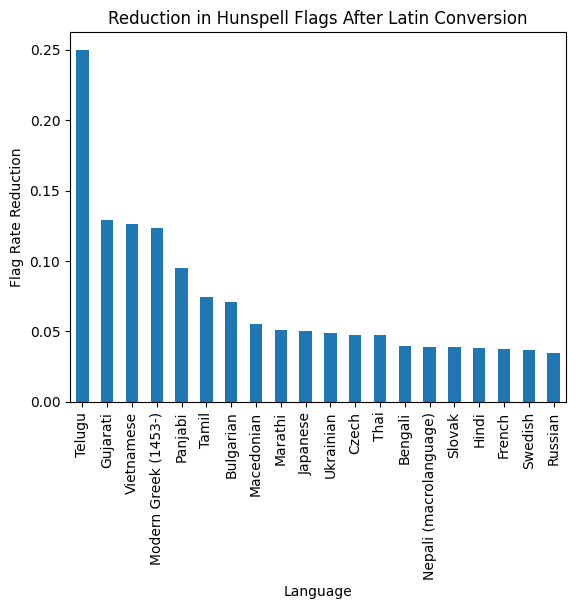

In [20]:
latin_improvement = (
    df.groupby("langdetect_lang_name")
    .apply(lambda x: x["hunspell_flag"].mean() - x["hunspell_latin_flag"].mean())
    .sort_values(ascending=False)
)

latin_improvement.head(20).plot.bar()

plt.title("Reduction in Hunspell Flags After Latin Conversion")
plt.ylabel("Flag Rate Reduction")
plt.xlabel("Language")
plt.show()

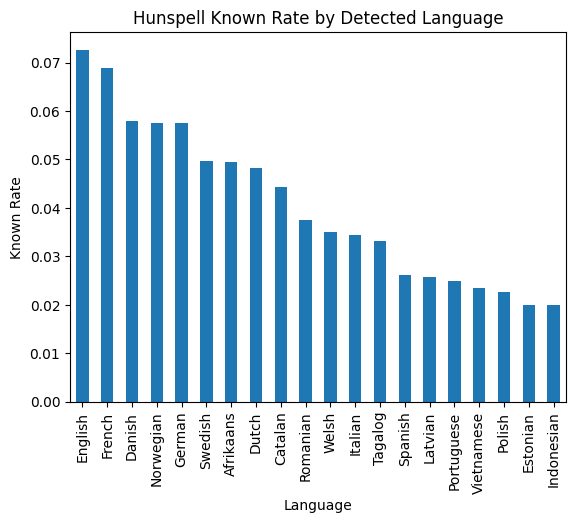

In [22]:
known_rate_lang = (
    df.groupby("langdetect_lang_name")["hunspell_orig_known"]
    .mean()
    .sort_values(ascending=False)
)

known_rate_lang.head(20).plot.bar()

plt.title("Hunspell Known Rate by Detected Language")
plt.ylabel("Known Rate")
plt.xlabel("Language")

plt.show()

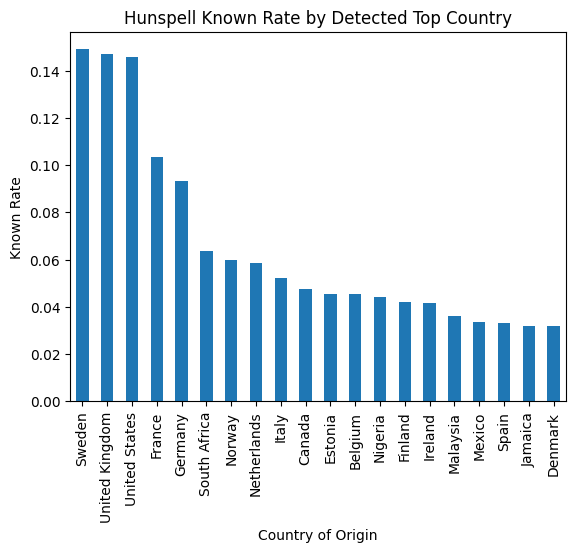

In [32]:
known_rate_lang = (
    df.groupby("top_country")["hunspell_orig_known"]
    .mean()
    .sort_values(ascending=False)
)

known_rate_lang.head(20).plot.bar()

plt.title("Hunspell Known Rate by Detected Top Country")
plt.ylabel("Known Rate")
plt.xlabel("Country of Origin")

plt.show()

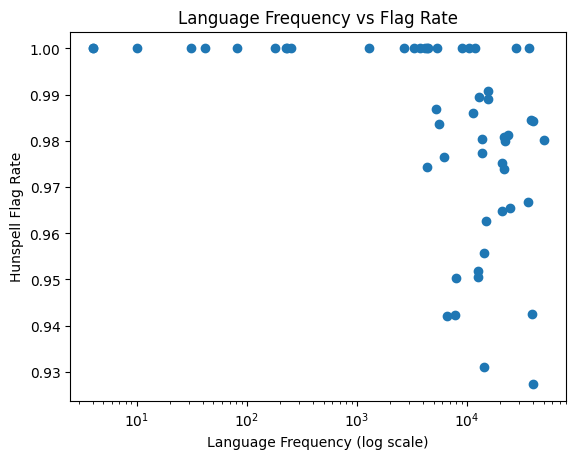

In [24]:
freq = df["langdetect_lang_name"].value_counts()
flag_rate = df.groupby("langdetect_lang_name")["hunspell_flag"].mean()

common = freq.index.intersection(flag_rate.index)

plt.scatter(freq[common], flag_rate[common])

plt.xscale("log")

plt.xlabel("Language Frequency (log scale)")
plt.ylabel("Hunspell Flag Rate")
plt.title("Language Frequency vs Flag Rate")

plt.show()

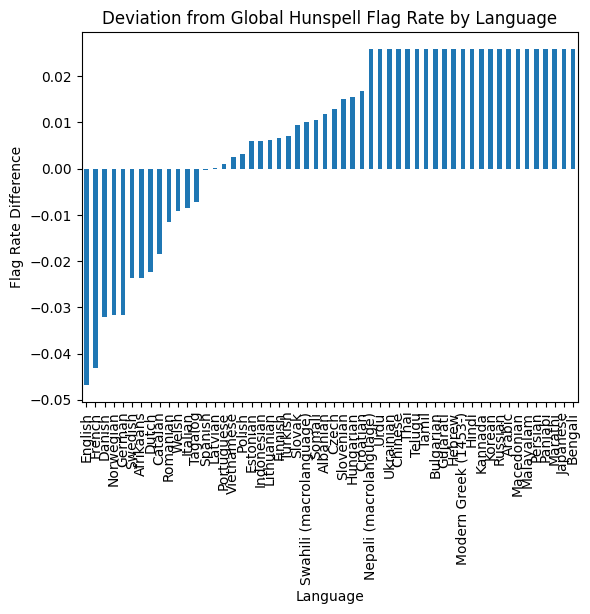

In [25]:
global_flag_rate = df["hunspell_flag"].mean()

flag_rate_lang = df.groupby("langdetect_lang_name")["hunspell_flag"].mean()

deviation = (flag_rate_lang - global_flag_rate).sort_values()

deviation.plot.bar()

plt.title("Deviation from Global Hunspell Flag Rate by Language")
plt.ylabel("Flag Rate Difference")
plt.xlabel("Language")

plt.show()

In [26]:
summary = pd.DataFrame({
    "frequency": df["langdetect_lang_name"].value_counts(),
    "flag_rate": df.groupby("langdetect_lang_name")["hunspell_flag"].mean()
})

summary["known_rate"] = 1 - summary["flag_rate"]

summary.sort_values("frequency", ascending=False).head(20)

,frequency,flag_rate,known_rate
langdetect_lang_name,,,
Indonesian,49929,0.980152,0.019848
Swahili (macrolanguage),40299,0.984292,0.015708
English,40025,0.927320,0.072680
German,39268,0.942498,0.057502
Somali,38187,0.984550,0.015450
Arabic,36900,1.000000,0.000000
Tagalog,36109,0.966795,0.033205
Korean,27914,1.000000,0.000000
Italian,24938,0.965555,0.034445


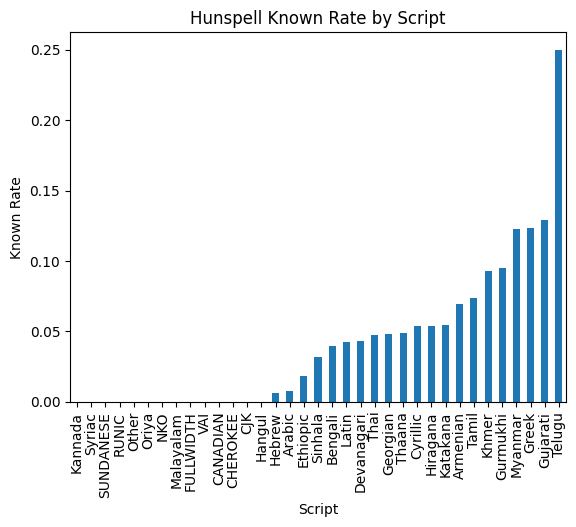

In [34]:
script_rate = (
    df.groupby("name_script")["hunspell_latin_known"]
    .mean()
    .sort_values()
)

script_rate.plot.bar()

plt.title("Hunspell Known Rate by Script")
plt.ylabel("Known Rate")
plt.xlabel("Script")

plt.show()